Continuing from makemore 3

* until now, we did something sensible. Count, calculate probabilities, sample (or infer) and evaluate.
* Now, we want to cast bigram char level language modeling on to neural network. This neural network will still be "bigram char level language modeling", it still receives single char as input, there is NN, with some weights (or parameters) and it's going to output probability distribution over the next char in the sequence.
* We will evaluate any setting of NN. And create a Loss function.
* Probability is high, is another way of saying loss is low.
* Softmax, logits

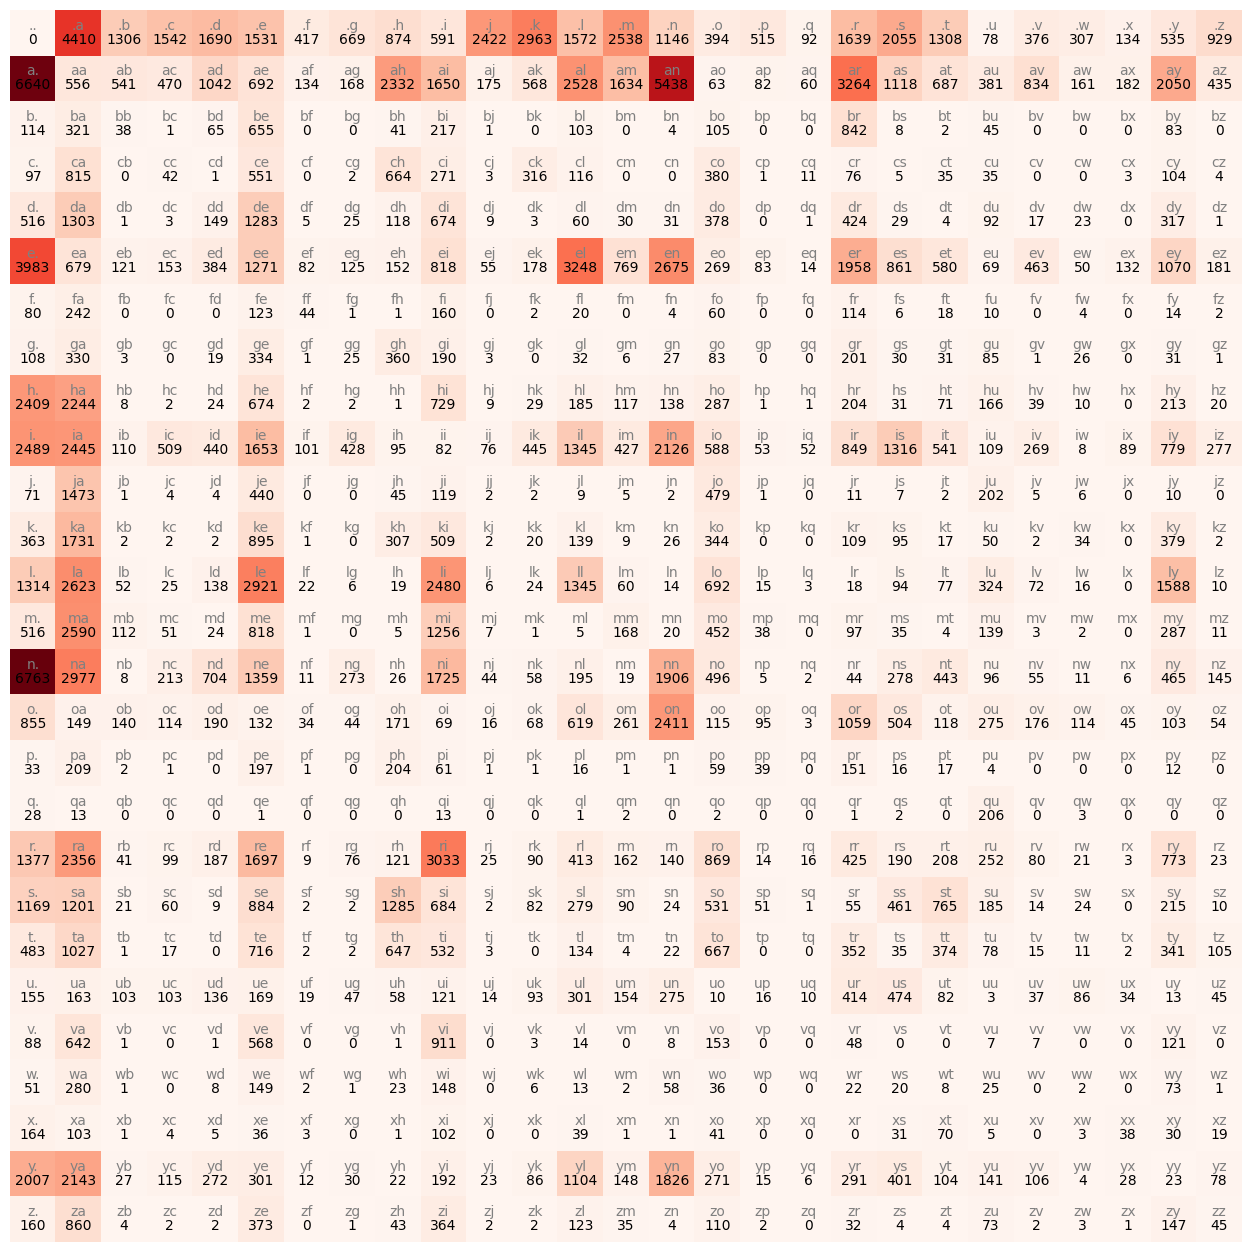

In [2]:
import torch
import matplotlib.pyplot as plt
%matplotlib inline

# Read names.txt
words = open('names.txt', 'r').read().splitlines()

# we will need 26 * 26 for all alphabets + 1 for start char
# so 27 * 27
N = torch.zeros((27, 27), dtype = torch.int32)

# a - z
chars = sorted(list(set(''.join(words))))
stoi = {s:i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0

# N will have bigram counter
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        index1 = stoi[ch1]
        index2 = stoi[ch2]
        N[index1, index2] += 1

itos = {i:s for s, i in stoi.items()}

plt.figure(figsize = (16, 16))
# This prints the whole matrix with color shades (weighed by count)
plt.imshow(N, cmap = 'Reds')

# iterate and add count and bigram
for i in range(27):
    for j in range(27):
        # bigram
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha = "center", va = "bottom", color = 'gray')
        # count (N[i, j].item() is count)
        plt.text(j, i, N[i, j].item(), ha = "center", va = "top", color = 'black')
plt.axis('off');

In [8]:
P = (N + 1).float()
P /= P.sum(1, keepdims = True) # will normalize every single row

# sample or infer
g = torch.Generator().manual_seed(912345678) 

for i in range(10):
    out = []
    indexX = 0
    while True:
        p = P[indexX]
        indexX = torch.multinomial(p, num_samples = 1, replacement = True, generator = g).item()
        out.append(itos[indexX])
        if indexX == 0:
            break
    print(''.join(out))

print('-'*30)
# Loss or Negative Log Likelihood
log_likelihood = 0.0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

nll = -log_likelihood
print(f'{nll/n=}') # Average of NLL (again convenience)

ja.
rik.
s.
a.
xusayremovianeleshay.
jol.
marynga.
ze.
ialetynyn.
gleelin.
------------------------------
nll/n=tensor(2.4544)


# Summary of straightforward way

We trained a respectable bigram character-level language model. And we saw that we both trained the model by looking at the counts of all the bigrams and normalizing the rows to get probability distributions. We saw that we can also then use those parameters of this model

* to perform sampling of new words. So we sample new names according to those distributions.
* And we also saw that we can evaluate the quality of this model.

The quality of this model is summarized in a single number, which is the negative log likelihood. 
The lower this number is, the better the model is because it is giving high probabilities to the actual next characters in all the bigrams in our training set. 

We've arrived at this model explicitly by doing something that felt sensible. We were just performing counts and then we were normalizing those counts.

# Moving on to NN based approach (will arrive at similar Loss)

In [13]:
# create training set of all bigrams

# iterate over all bigrams
# instead of count, we will create training set

xs = [] # inputs
ys = [] # targets
for w in words[:1]: # looping over just one example for easier understanding to start with
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        index1 = stoi[ch1]
        index2 = stoi[ch2]
        print(ch1, ch2)
        xs.append(index1)
        ys.append(index2)

xs = torch.tensor(xs) 
ys = torch.tensor(ys)
# also there is torch.Tensor and is float type. While torch.tensor is int type. Suggestion from Andrej is to read documentation.

. e
e m
m m
m a
a .


In [12]:
print(f'{xs=}')
print(f'{ys=}')

xs=tensor([ 0,  5, 13, 13,  1])
ys=tensor([ 5, 13, 13,  1,  0])


when input to NN is 0, desired label is 5
when input to NN is 5, desired label is 13
..
when input to NN is 1, desired label is 0

basically 5 inputs from this dataset (or word)

In [15]:
# We cannot plug these integers as is into Neural network.
# Common way of encoding these integers is one-hot encoding. 
# Basically, for example 13, every number is 0 except 13 will be 1.

import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes = 27)
print(f'{xenc=}')

xenc=tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0]])


In [16]:
xenc.shape

torch.Size([5, 27])

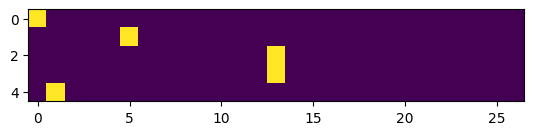

In [17]:
plt.imshow(xenc)

This is how we can encode integers into vectors, and these vectors feed into NN.

In [18]:
# We want xenc to be float type, but xenc is int, because our xs is int64 (because we use torch.tensor above)
# repeating above steps, but with cast to float

xenc = F.one_hot(xs, num_classes = 27).float()
print(f'{xenc=}')

xenc=tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])


In [27]:
# weights. Generating, 27 weights and choosing 1 Neuron
W = torch.randn((27, 1)) # These are random numbers.
print(f'{W=}')
# [5, 27] * [27, 1] = [5, 1]
print(f'{xenc @ W=}')


W=tensor([[-0.5658],
        [ 1.8807],
        [ 0.3354],
        [ 0.2249],
        [-1.7801],
        [ 1.6163],
        [-0.4634],
        [ 2.1937],
        [-0.4594],
        [ 0.2491],
        [-0.8407],
        [ 0.9064],
        [ 1.2513],
        [-0.7215],
        [-0.3675],
        [ 0.5668],
        [-1.1632],
        [-0.6357],
        [ 1.8214],
        [ 0.1311],
        [ 0.7704],
        [-0.8380],
        [-0.4853],
        [-0.0496],
        [-1.6150],
        [-0.3243],
        [-1.8126]])
xenc @ W=tensor([[-0.5658],
        [ 1.6163],
        [-0.7215],
        [-0.7215],
        [ 1.8807]])


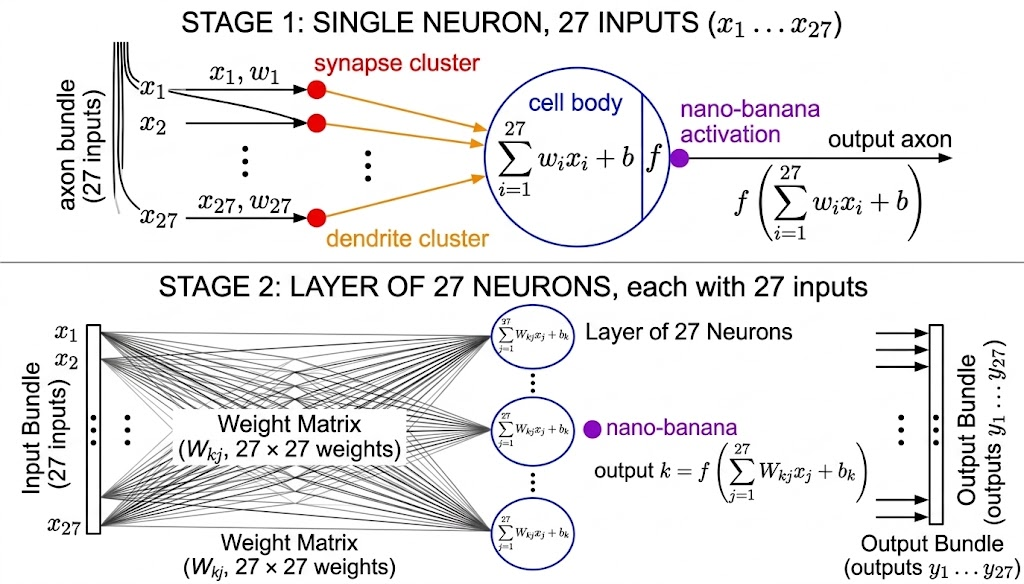

In [39]:
# weights. Generating, 27 weights and choosing 27 Neurons
W = torch.randn((27, 27))
# [5, 27] * [27, 27] = [5, 27]
print(f'{(xenc @ W).shape=}')
print(f'{xenc @ W=}')

(xenc @ W).shape=torch.Size([5, 27])
xenc @ W=tensor([[ 0.0632,  0.0327,  0.1026, -0.2106, -0.2586,  0.0819,  2.6662,  0.2322,
          1.2291, -0.8891, -0.1599,  0.2872, -1.1043, -0.9435,  0.2976, -0.9493,
         -0.8903,  0.7721, -0.9746, -0.1005,  0.4857,  0.2398, -1.0791,  0.4869,
         -1.0404,  0.8227,  1.4062],
        [-0.1059, -0.0144,  1.3716, -0.4462,  1.3007,  0.4538,  0.4124, -0.6312,
         -0.6581,  1.5117, -1.5844,  1.0533,  0.3385,  0.6480,  0.2966,  0.6791,
          0.1704, -0.5839,  0.6097,  1.4386,  0.3869, -1.2201,  0.6988, -0.5225,
          1.4431, -0.1862, -1.5910],
        [-1.1627,  0.3961, -0.4087,  0.3191,  0.6542,  0.5130,  0.1509,  1.1631,
         -2.5671, -1.1998,  0.6665, -1.7740, -0.3535, -0.4232, -1.7549, -0.8921,
         -0.9767, -1.1921, -2.2622,  0.0736,  0.0666, -1.4886, -0.2686, -0.3706,
         -0.3727, -0.3550,  0.3746],
        [-1.1627,  0.3961, -0.4087,  0.3191,  0.6542,  0.5130,  0.1509,  1.1631,
         -2.5671, -1.1998,  0.666

In [40]:
(xenc @ W)[3, 13]
# What this is telling is, the firing rate of 13th neuron, looking at 3rd example or input.

tensor(-0.4232)

In [41]:
# xenc @ W is basically efficient way of multiplying of lots of input examples in a batch, and lots of neurons.
# Where all those neurons have weights in columns.
print(f'{xenc[3]=}')
print(f'{W[:, 13]=}')
print(f'{(xenc[3] * W[:, 13]).sum()=}')

xenc[3]=tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])
W[:, 13]=tensor([-0.9435, -1.2849, -1.4957, -0.8675, -1.4437,  0.6480,  0.9488,  1.2755,
         1.7597,  0.3553, -0.9457,  1.0061,  0.0720, -0.4232,  0.6006,  0.1459,
        -0.8283,  0.2378, -0.7917, -0.2957,  0.2090,  0.1944, -0.7721,  0.5128,
         0.6962,  1.7676,  0.4735])
(xenc[3] * W[:, 13]).sum()=tensor(-0.4232)


* This NN has 27 inputs and 27 neurons.
* These don't have bias
* These don't have non linearity like tanh
* These don't have any other layer, just 1, dumbest, smallest, simple, single layer

* So for each number, we will get 27 probabilities. Highest probability is basically our sample or inference.

* So, like earlier, we had counts, and we converted this counts to probabilities by normalizing it.
* We want NN to come up with something like that.
* Right now, we have random numbers between negative numbers to positive numbers (on both sides of 0). This cannot be probabilities or counts.
* Probabilities have some properties, like they are 
    * positive numbers
    * they sum to 1
* So how do we interpret numbers from NN?
    * NN is giving us log counts (exp(x))
    * if x<0, exp(x) is a number between 0 and 1
    * if x>0, exp(x) is a number between 1 and inf

In [42]:
(xenc @ W).exp()

tensor([[ 1.0652,  1.0333,  1.1081,  0.8101,  0.7722,  1.0854, 14.3845,  1.2613,
          3.4180,  0.4110,  0.8522,  1.3326,  0.3314,  0.3893,  1.3467,  0.3870,
          0.4105,  2.1643,  0.3773,  0.9044,  1.6253,  1.2709,  0.3399,  1.6273,
          0.3533,  2.2765,  4.0804],
        [ 0.8996,  0.9857,  3.9417,  0.6400,  3.6719,  1.5743,  1.5104,  0.5320,
          0.5179,  4.5344,  0.2051,  2.8670,  1.4028,  1.9118,  1.3453,  1.9722,
          1.1858,  0.5577,  1.8399,  4.2148,  1.4725,  0.2952,  2.0114,  0.5930,
          4.2337,  0.8301,  0.2037],
        [ 0.3126,  1.4860,  0.6645,  1.3759,  1.9236,  1.6703,  1.1629,  3.1997,
          0.0768,  0.3013,  1.9474,  0.1696,  0.7022,  0.6550,  0.1729,  0.4098,
          0.3766,  0.3036,  0.1041,  1.0763,  1.0689,  0.2257,  0.7645,  0.6903,
          0.6889,  0.7012,  1.4544],
        [ 0.3126,  1.4860,  0.6645,  1.3759,  1.9236,  1.6703,  1.1629,  3.1997,
          0.0768,  0.3013,  1.9474,  0.1696,  0.7022,  0.6550,  0.1729,  0.4098

So, no negative numbers. These are like counts, they are positive numbers.
Never be negative numbers. 

(I don't know why our weights could be assigned with such numbers, or non-negative numbers) - will clarify later

In [45]:
# so putting our knowledge together

# also don't have to break my head why it is called logits, but it is standard or a convention
logits = xenc @ W # log-counts, 

# these 2 lines are called softmax
counts = logits.exp() # equivalent N, or get fake counts
probs = counts / counts.sum(1, keepdims = True)

print(f'{probs=}')

print('These are basically differential operations, on which we can backpropagate.')
print('This is becoming similar to micrograd that I learned last week')
print('so, the prob is telling us for 5 inputs, whats the most probable next character for each 5 input')

probs=tensor([[0.0235, 0.0228, 0.0244, 0.0178, 0.0170, 0.0239, 0.3167, 0.0278, 0.0753,
         0.0090, 0.0188, 0.0293, 0.0073, 0.0086, 0.0297, 0.0085, 0.0090, 0.0477,
         0.0083, 0.0199, 0.0358, 0.0280, 0.0075, 0.0358, 0.0078, 0.0501, 0.0898],
        [0.0196, 0.0215, 0.0858, 0.0139, 0.0799, 0.0343, 0.0329, 0.0116, 0.0113,
         0.0987, 0.0045, 0.0624, 0.0305, 0.0416, 0.0293, 0.0429, 0.0258, 0.0121,
         0.0400, 0.0917, 0.0320, 0.0064, 0.0438, 0.0129, 0.0921, 0.0181, 0.0044],
        [0.0132, 0.0627, 0.0281, 0.0581, 0.0812, 0.0705, 0.0491, 0.1351, 0.0032,
         0.0127, 0.0822, 0.0072, 0.0296, 0.0277, 0.0073, 0.0173, 0.0159, 0.0128,
         0.0044, 0.0454, 0.0451, 0.0095, 0.0323, 0.0291, 0.0291, 0.0296, 0.0614],
        [0.0132, 0.0627, 0.0281, 0.0581, 0.0812, 0.0705, 0.0491, 0.1351, 0.0032,
         0.0127, 0.0822, 0.0072, 0.0296, 0.0277, 0.0073, 0.0173, 0.0159, 0.0128,
         0.0044, 0.0454, 0.0451, 0.0095, 0.0323, 0.0291, 0.0291, 0.0296, 0.0614],
        [0.0316, 0

* above, 2 lines are called softmax
* it is a way of taking outputs of NN, and outputs probability distribution that sums to 1
* this is kind of normalization
* softmax makes output of NN a probability.

* Remember, probability has following properties
    * It sums to 1
    * It is positive number

#### Softmax  
* basically takes in logits, logits.exp
* and then convert to probabilities  
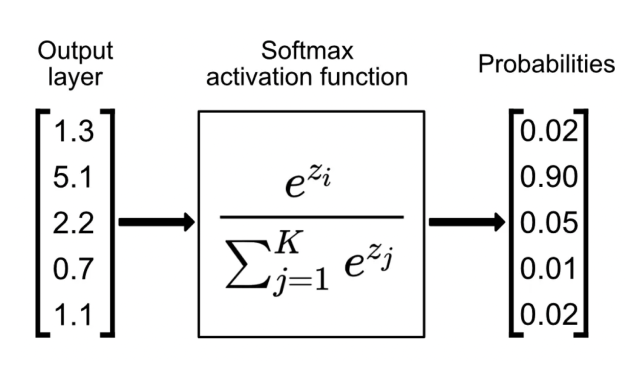

### To put things into perspective. 
# This is forward pass.
Everything here is differential layer.
Everything here can be backpropagated to.
```python
xenc = F.one_hot(xs, num_classes = 27).float()
logits = xenc @ W # Multiple and add

# these 2 lines are called softmax
counts = logits.exp() # exp - Can be backpropagate through
probs = counts / counts.sum(1, keepdims = True) # division and sum - # Can be backpropagate through
```

In [47]:
nlls = torch.zeros(5)
for i in range(5):
    # i-th bigram:
    x = xs[i].item() # input character index
    y = ys[i].item() # label character index
    print('--------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
    print(f'Meaning, input to NN is {itos[x]}, predict {itos[y]} (or input to NN is indexe {x}, predict {y})')
    print('input to the neural net:', x)
    print('output probabilities from the neural net:', probs[i]) # probs coming from softmax
    print('label (actual next character):', y)
    p = probs[i, y]
    print('probability assigned by the net to the the correct character:', p.item())
    logp = torch.log(p)
    print('log likelihood:', logp.item())
    nll = -logp
    print('negative log likelihood:', nll.item())
    nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .e (indexes 0,5)
Meaning, input to NN is ., predict e (or input to NN is indexe 0, predict 5)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0235, 0.0228, 0.0244, 0.0178, 0.0170, 0.0239, 0.3167, 0.0278, 0.0753,
        0.0090, 0.0188, 0.0293, 0.0073, 0.0086, 0.0297, 0.0085, 0.0090, 0.0477,
        0.0083, 0.0199, 0.0358, 0.0280, 0.0075, 0.0358, 0.0078, 0.0501, 0.0898])
label (actual next character): 5
probability assigned by the net to the the correct character: 0.02389681152999401
log likelihood: -3.7340102195739746
negative log likelihood: 3.7340102195739746
--------
bigram example 2: em (indexes 5,13)
Meaning, input to NN is e, predict m (or input to NN is indexe 5, predict 13)
input to the neural net: 5
output probabilities from the neural net: tensor([0.0196, 0.0215, 0.0858, 0.0139, 0.0799, 0.0343, 0.0329, 0.0116, 0.0113,
        0.0987, 0.0045, 0.0624, 0.0305, 0.0416, 0.0293, 0.0429, 0.0258, 0.0121,
        0.0400, 0.0917

* 3.3447425365448 is the loss on how NN is doing based on one example "emma"
* We will have to optimize this NN. (we can however try another random assignment - but that's amateur way to optimize)
# How to optimize?

    * We start with random guess and commit to it, even though it is not good.
    * Now, we have loss function. This loss is made of only of differential operations.
    * We can minimize loss, by tuning Ws, by computing gradients of the loss w.r.t W matrices.
    * We can tune W, minimize loss. And find good setting for W.

    
* From here, things will start to look like micrograd.

In [49]:
# At https://youtu.be/PaCmpygFfXo?si=KIb7b6xw-kD_z_Qs&t=5763

# forward pass
xenc = F.one_hot(xs, num_classes = 27).float()
logits = xenc @ W # Multiple and add
counts = logits.exp() # exp - Can be backpropagate through
probs = counts / counts.sum(1, keepdims = True) # division and sum - # Can be backpropagate through


## calculating Loss

In [51]:
print(f'{probs.shape=}')
print(f'{probs[0, 5]=}')
print(f'{probs[1, 13]=}')
print(f'{probs[2, 13]=}')
print(f'{probs[3, 1]=}')
print(f'{probs[4, 0]=}')

probs.shape=torch.Size([5, 27])
probs[0, 5]=tensor(0.0239)
probs[1, 13]=tensor(0.0416)
probs[2, 13]=tensor(0.0277)
probs[3, 1]=tensor(0.0627)
probs[4, 0]=tensor(0.0316)


What's happening here is, if we go back to our training dataset of xs and ys
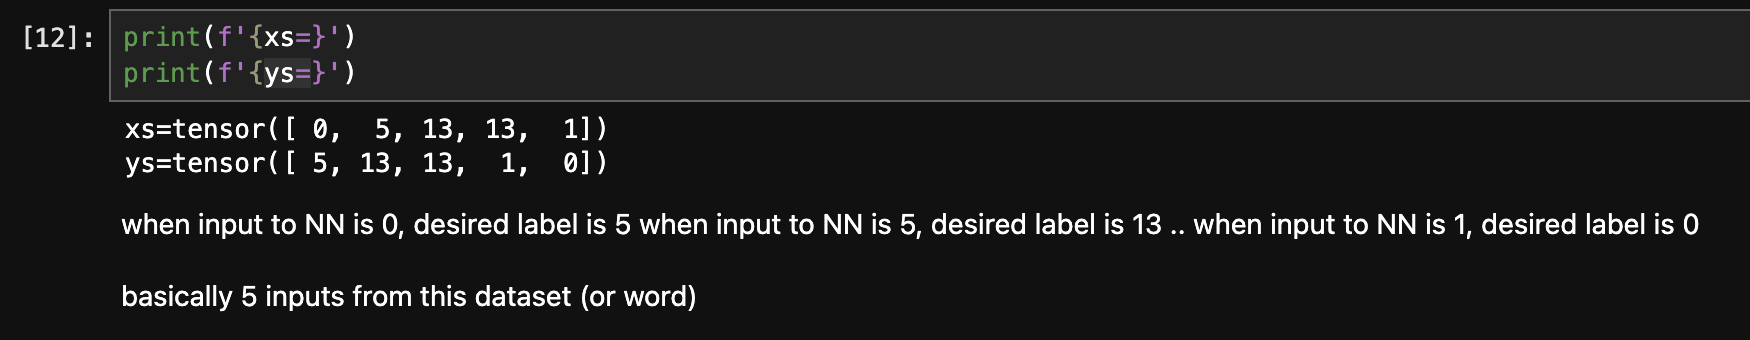

We want to get probabilities for 'e' (index: 5), when '.' (index: 0) is input. 
Right now, it is 0.0239. Meaning NN is predicting there is 2% chance 'e' will be predicted with current "random" weights.

Apparently, there is a nicer way to do that. 

In [53]:
print(f'{torch.arange(5)=}')
print(f'{probs[torch.arange(5), ys]=}')

torch.arange(5)=tensor([0, 1, 2, 3, 4])
probs[torch.arange(5), ys]=tensor([0.0239, 0.0416, 0.0277, 0.0627, 0.0316])


as we can see, we got probabilities that NN assigns for our input xs.

We should actually get log, average (or mean) and negative log, likelihood

In [55]:
loss = -probs[torch.arange(5), ys].log().mean()
loss

tensor(3.3447)

# Another attempt at building NN (similar to micrograd)

Now, we are basically doing what we did in micrograd

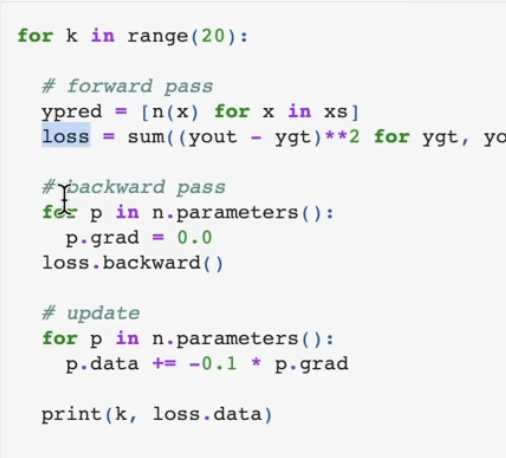

* forward pass (calculate loss)
* backward pass (calculate gradient)
* update

In [71]:
# randomly initialize 27 neurons' weights, each neuron receives 27 inputs
g = torch.Generator().manual_seed(912345678)
W = torch.randn((27, 27), generator = g, requires_grad = True)
# forward pass
xenc = F.one_hot(xs, num_classes = 27).float()
logits = xenc @ W # Multiple and add
counts = logits.exp() # exp - Can be backpropagate through
probs = counts / counts.sum(1, keepdims = True) # division and sum - # Can be backpropagate through
loss = -probs[torch.arange(5), ys].log().mean()

# backward pass

In [72]:
# in pytorch, setting grad to 0
W.grad = None # set the gradient to zero 
loss.backward() # something magical happened. 
# pytorch knows all the dependencies and all mathematical operations.
# .backward() filled in the gradients of all the intermediates all the way back to W (which are paramters of our NN)
# Remember W grad was set to W, but after loss.backward updated gradients for W. W.grad is no more 0.0s

In [73]:
print(loss.item())

3.2373435497283936


In [74]:
# updates the tensor
W.data += -0.1 * W.grad